In [25]:
import numpy as np
import matplotlib.pyplot as plt

In [26]:
alpha = 1 # коэффициент роста жертв
beta = 0.05 # коэффициент убыли жертв из-за хищников
delta = 0.05# коэффициент роста хищников
gamma = 1 # коэффициент убыли хищников

In [27]:
x0 = 40  #  жертвы
y0 = 9  #  хищники

In [28]:
t_max = 200
dt = 0.1
t = np.arange(0, t_max, dt)

In [29]:
def lotka_volterra_numerical(x0, y0, alpha, beta, delta, gamma, t):
    x = np.zeros(len(t))
    y = np.zeros(len(t))
    x[0] = x0
    y[0] = y0

    for i in range(1, len(t)):
        k1_x = alpha * x[i - 1] - beta * x[i - 1] * y[i - 1]
        k1_y = delta * x[i - 1] * y[i - 1] - gamma * y[i - 1]

        k2_x = alpha * (x[i - 1] + k1_x * dt) - beta * (x[i - 1] + k1_x * dt) * (y[i - 1] + k1_y * dt)
        k2_y = delta * (x[i - 1] + k1_x * dt) * (y[i - 1] + k1_y * dt) - gamma * (y[i - 1] + k1_y * dt)

        x[i] = x[i - 1] + k2_x * dt
        y[i] = y[i - 1] + k2_y * dt

    return x, y

In [30]:
def lotka_volterra_analytical(x0, y0, alpha, beta, delta, gamma, t):
    # T = 2 * np.pi / np.sqrt(alpha * gamma)
    # A = np.sqrt((alpha / beta) * (gamma / delta))
    # 
    # x_analytical = A * np.cos(np.sqrt(alpha * gamma) * t) + (x0 + y0) / 2
    # y_analytical = A * np.sin(np.sqrt(alpha * gamma) * t) + (x0 - y0) / 2
    
    epsilon = 0.001
    phi = np.arctan((y0 - (alpha / beta)) / (x0 - (delta / gamma)))
    a = (x0 - (delta / gamma)) / np.cos(phi)
    
    omega1 = gamma * beta / delta
    omega2 = delta * alpha / beta

    N1 = (
            (gamma / delta) +
            a * np.cos(omega1 * t + phi) +
            epsilon * (
                    -a ** 2 / 2 * (np.sin(2 * omega1 * t + 2 * phi) - np.sin(2 * phi)) +
                    a ** 2 / 4 * (np.cos(2 * omega1 * t + 2 * phi) - np.cos(2 * phi))
            )
    )

    N2 = (
            (alpha / beta) +
            a * np.sin(omega2 * t + phi) +
            epsilon * (
                    a ** 2 / 2 * (np.sin(2 * omega2 * t + 2 * phi) - np.sin(2 * phi)) -
                    a ** 2 / 4 * (np.cos(2 * omega2 * t + 2 * phi) - np.cos(2 * phi))
            )
    )

    return N1, N2

In [31]:
x_numerical, y_numerical = lotka_volterra_numerical(x0, y0, alpha, beta, delta, gamma, t)
x_analytical, y_analytical = lotka_volterra_analytical(x0, y0, alpha, beta, delta, gamma, t)

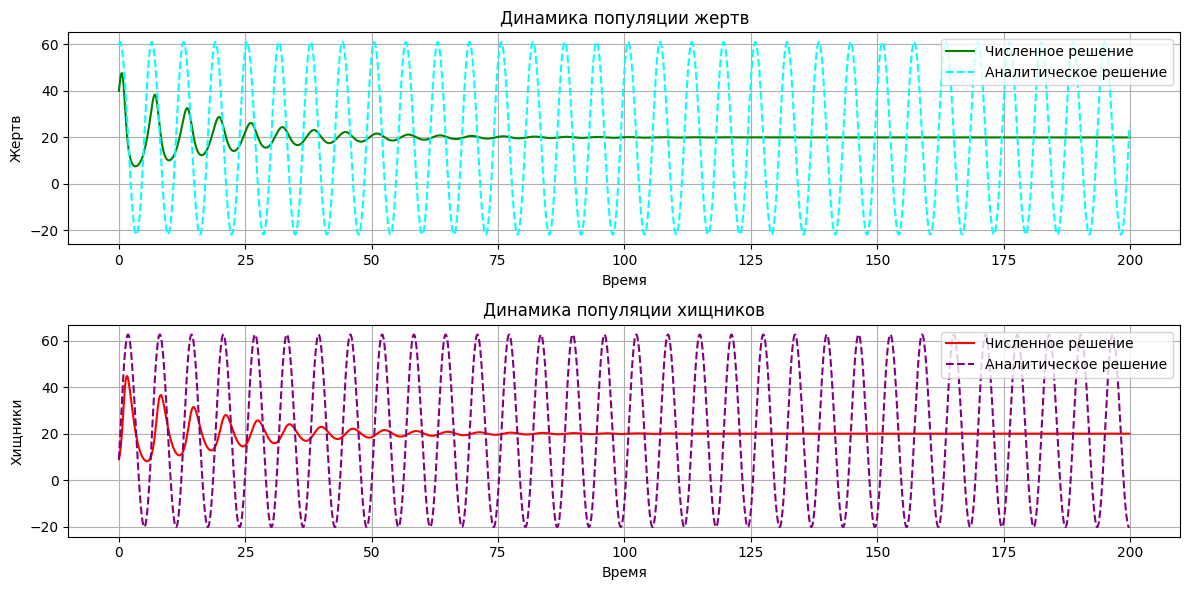

In [32]:
plt.figure(figsize=(12, 6))

plt.subplot(2, 1, 1)
plt.plot(t, x_numerical, label='Численное решение', color='green')
plt.plot(t, x_analytical[:len(t)], label='Аналитическое решение', color='cyan', linestyle='dashed')
plt.title('Динамика популяции жертв')
plt.xlabel('Время')
plt.ylabel('Жертв')
plt.legend()
plt.grid()

plt.subplot(2, 1, 2)
plt.plot(t, y_numerical, label='Численное решение', color='red')
plt.plot(t, y_analytical[:len(t)], label='Аналитическое решение', color='purple', linestyle='dashed')
plt.title('Динамика популяции хищников')
plt.xlabel('Время')
plt.ylabel('Хищники')
plt.legend()
plt.grid()

plt.tight_layout()
plt.show()